In [228]:
import pandas as pd
import numpy as np
from DATA.stock_invest_function import *
from datetime import datetime, timedelta
import warnings

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [229]:
save_path = r"C:\Users\MetaM\PycharmProjects\stock_forecast\DATA"

tic_name = 'ANET'
hs_code = '848690'
item_name = 'PSR'
st_date = '2010-01-01'
end_date = '2025-07-31'
# 오늘 날짜 구하기 (YYYY-MM-DD)
today_date = pd.to_datetime(datetime.today().date())

apikey = 'hT0gAk87j9xZx4PlBApvBqfVL5IahvgV'

db_info = {
    'host' : get_db_host(),
    # 'host' : 'hystox74.synology.me',
    'port' : 3307,
    'user' : 'stox7412',
    'password' : 'Apt106503!~',
    'database' : 'investar'
}

In [230]:
## 미국 기업 재무정보
fundq_df = fetch_table_data(db_info, 'US_fundq')

## 미국 수출 데이터
trade_df = fetch_table_data(db_info, 'us_trade_monthly_data_with_forecast')
#
tickers = [tic_name]
wide_df = get_FMP_data(tickers, apikey)
long_df = reshape_FMP_data(wide_df)
#
accounting_name = 'revenue'
FMP_df = long_df[(long_df['ticker'] == tic_name) & (long_df['accounting_item'] == accounting_name)][['date', 'value']].copy()
FMP_df.rename(columns={'value': tic_name}, inplace=True)

✅ 'US_fundq' 테이블에서 1334117건의 데이터를 가져왔습니다.
✅ 'us_trade_monthly_data_with_forecast' 테이블에서 67574건의 데이터를 가져왔습니다.


Fetching income statements: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it]


In [231]:
endog_df = fundq_df[fundq_df['ticker'] == tic_name][['date', 'saleq']]
endog_df.rename(columns={'saleq' : tic_name}, inplace=True)
endog_month_df = fundq_df[fundq_df['ticker'] == tic_name][['date', 'saleq']]
endog_month_df.rename(columns={'saleq' : tic_name}, inplace=True)

# 날짜 처리 및 분기당 마지막 날짜만 추출
endog_df['date'] = pd.to_datetime(endog_df['date'])
endog_df['quarter'] = endog_df['date'].dt.to_period('Q')
endog_df = endog_df.sort_values('date').groupby('quarter').last().reset_index(drop=True)
endog_df = endog_df[(endog_df['date'] >= st_date) & (endog_df['date'] <= end_date)]

temp_df = trade_df[trade_df['hs_code_6d'] == hs_code][['date','expDlr']]

# 중복 제거
target_export_df = temp_df.drop_duplicates(subset=['date'])

# date를 datetime으로 변환
target_export_df['date'] = pd.to_datetime(target_export_df['date'])

# 분기 추출 및 그룹화
target_export_df['quarter'] = target_export_df['date'].dt.to_period('Q')
quarterly_sum_df = target_export_df.groupby('quarter')['expDlr'].sum().reset_index()

# datetime 변환 후 추가 계산
quarterly_sum_df['quarter'] = quarterly_sum_df['quarter'].dt.to_timestamp()
quarterly_sum_df['export_qoq_change'] = quarterly_sum_df['expDlr'].pct_change(periods=1)
quarterly_sum_df['export_yoy_change'] = quarterly_sum_df['expDlr'].pct_change(periods=4)
quarterly_sum_df['date_month'] = quarterly_sum_df['quarter'] + pd.offsets.QuarterEnd(0)
quarterly_sum_df['date'] = pd.to_datetime(quarterly_sum_df['date_month'])

# date를 인덱스로 설정
quarterly_sum_df.set_index('date', inplace=True)
# ✅ (선택적으로 quarter 컬럼 제거)
quarterly_sum_df.drop(columns='quarter', inplace=True)

quarterly_sum_df = quarterly_sum_df.reset_index()

## nan value  제거
quarterly_sum_df = quarterly_sum_df.iloc[8:]
# 💡 로그변환 제거 → 원시 endog_var 사용
# 💡 외생 변수 exog_var는 표준화(Z-score) 적용
scaler = StandardScaler()
quarterly_sum_df['exog_scaled'] = scaler.fit_transform(quarterly_sum_df[['export_yoy_change']])

merged = merge_endog_exog_data(
    endog_df = endog_df,
    exog_df = quarterly_sum_df,
    endog_col=tic_name,
    exog_col='export_yoy_change',
    start_date= st_date,
    end_date= end_date
)
merged = merged.drop_duplicates(subset=['date', 'endog_var'], keep='first').reset_index()

In [232]:
endog_df

,date,AMAT
40,2010-03-31,1848.902
41,2010-06-30,2295.540
42,2010-09-30,2517.790
43,2010-12-31,2886.435
44,2011-03-31,2686.000
...,...,...
98,2024-09-30,6778.000
99,2024-12-31,7045.000
100,2025-03-31,7166.000
101,2025-06-30,7100.000


✅ 로그 변환 적용
📎 외생변수 'exog_var' 포함
✅ 로그 변환 적용
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 1, 0), seasonal_order=(1, 0, 1, 4), AIC=-121.33


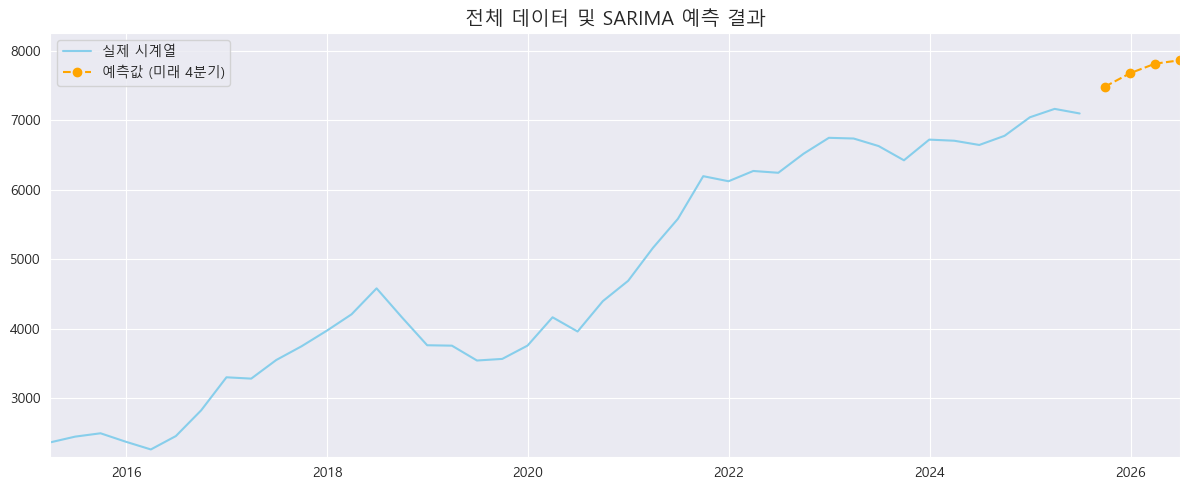


📈 미래 4분기 예측 결과:
2025-09-30    7486.587359
2025-12-31    7680.993554
2026-03-31    7817.235193
2026-06-30    7867.120444
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   0.556041   0.967821
8   2.501981   0.961639
12  3.284564   0.993180


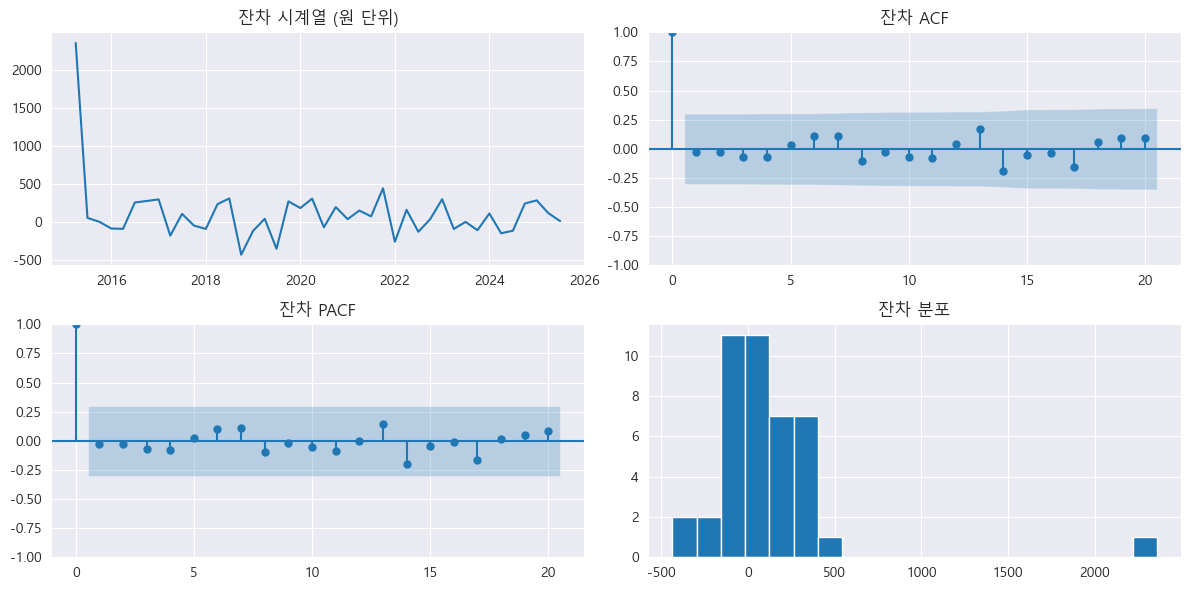

In [233]:
revenue_forecasts_with_exog = forecast_future_4q_with_sarima(merged, value_col='endog_var', exog_col='exog_var', fixed_variable=0, use_log=True)

✅ 로그 변환 적용
✅ 로그 변환 적용
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 1, 0), seasonal_order=(1, 0, 1, 4), AIC=-118.65


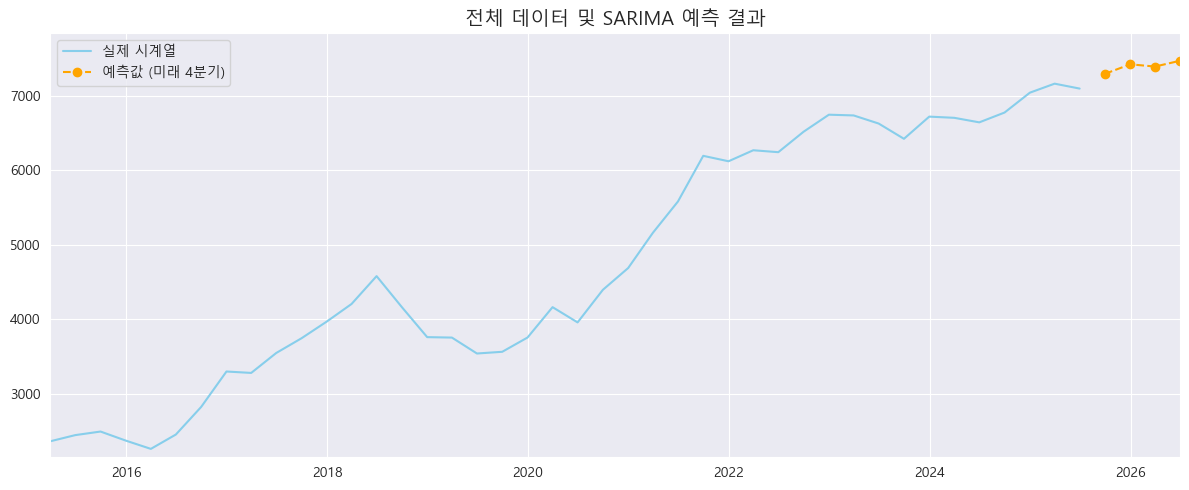


📈 미래 4분기 예측 결과:
2025-09-30    7298.182277
2025-12-31    7426.182121
2026-03-31    7395.929239
2026-06-30    7473.929808
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   0.601366   0.962912
8   2.620709   0.955864
12  3.193605   0.994016


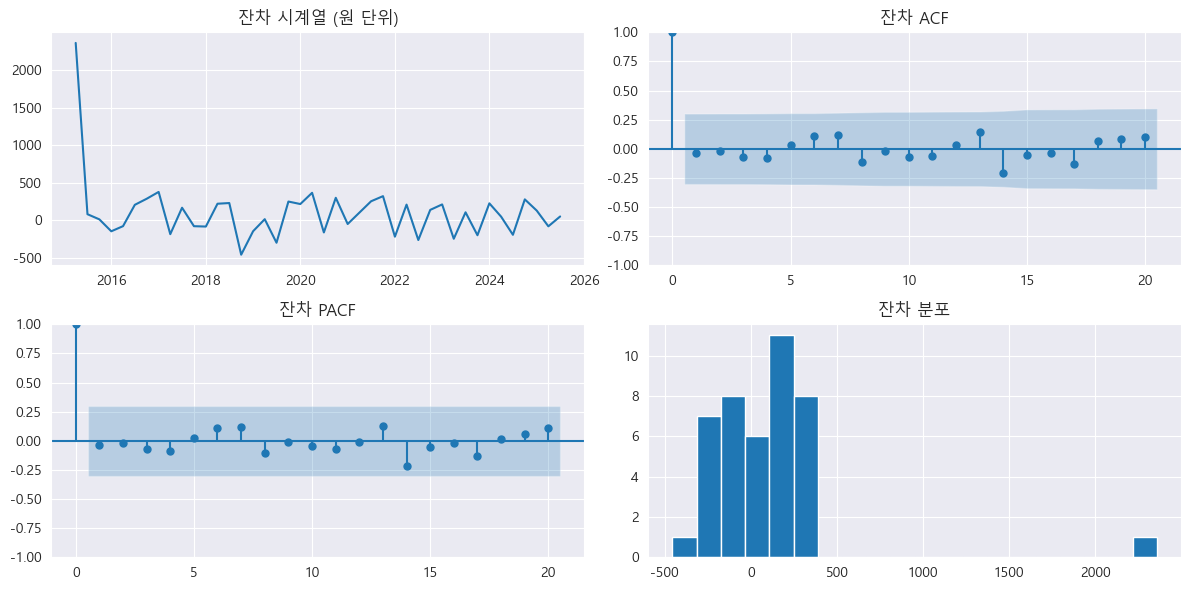

In [234]:
 # 외생변수 포함, 로그 사용, 고정 파라미터로 실행
revenue_forecasts_without_exog = forecast_future_4q_with_sarima(merged, value_col='endog_var', exog_col= None, fixed_variable=0)

In [235]:
# 🔁 결과 저장용 리스트
ratios_timeseries = []

for ticker in tqdm(tickers):
    try:
        url = f"https://financialmodelingprep.com/api/v3/ratios/{ticker}?period=quarter&limit=1000&apikey={apikey}"
        response = requests.get(url)
        data = response.json()

        if isinstance(data, list):
            for entry in data:
                ratios_timeseries.append({
                    'ticker': ticker,
                    'date': entry.get('date'),
                    'PER': entry.get('priceEarningsRatio'),
                    'PBR': entry.get('priceToBookRatio'),
                    'PSR': entry.get('priceToSalesRatio'),
                    'ROE': entry.get('returnOnEquity'),
                    'ROA': entry.get('returnOnAssets'),
                    'DividendPayout': entry.get('payoutRatio')
                })
        else:
            print(f"[⚠️ 없음] {ticker}: 데이터 구조가 예상과 다름")

    except Exception as e:
        print(f"[❌ 오류] {ticker}: {e}")

# 📊 DataFrame으로 변환 및 정렬
df_ratios = pd.DataFrame(ratios_timeseries)
df_ratios.sort_values(by=['ticker', 'date'], inplace=True)

endog_ratio_df = df_ratios[(df_ratios['ticker'] == tic_name)][['date', 'PSR']].copy()

# ✅ Step 1: 날짜 형식 변환
endog_ratio_df['date'] = pd.to_datetime(endog_ratio_df['date'])

# ✅ Step 2: 월 기준으로 분기 판단
def get_standard_quarter(month):
    if month in [1, 2, 3]:
        return 'Q1'
    elif month in [4, 5, 6]:
        return 'Q2'
    elif month in [7, 8, 9]:
        return 'Q3'
    elif month in [10, 11, 12]:
        return 'Q4'
    else:
        return None

# ✅ Step 3: 분기에 따른 일반 분기 종료일 매핑
def get_quarter_end_date(row):
    year = row['date'].year
    quarter = row['quarter']
    if quarter == 'Q1':
        return pd.Timestamp(year=year, month=3, day=31)
    elif quarter == 'Q2':
        return pd.Timestamp(year=year, month=6, day=30)
    elif quarter == 'Q3':
        return pd.Timestamp(year=year, month=9, day=30)
    elif quarter == 'Q4':
        return pd.Timestamp(year=year, month=12, day=31)
    else:
        return pd.NaT

# ✅ Step 4: 파생 변수 추가
endog_ratio_df['quarter'] = endog_ratio_df['date'].dt.month.apply(get_standard_quarter)
endog_ratio_df['aligned_date'] = endog_ratio_df.apply(get_quarter_end_date, axis=1)

# 기존 'date' 칼럼 제거
endog_ratio_df.drop(columns=['date'], inplace=True)
# 'aligned_date' 칼럼을 'date'로 이름 변경
endog_ratio_df.rename(columns={'aligned_date': 'date'}, inplace=True)

# FMP 데이터 날짜 수정 및 검증 코드
print("=== FMP 데이터 날짜 수정 프로세스 시작 ===")

# 1. 원본 데이터 상태 확인
print("\n📊 원본 데이터 상태:")
print(f"전체 레코드 수: {len(endog_ratio_df)}")
print(f"날짜 컬럼 데이터 타입: {endog_ratio_df['date'].dtype}")
print(f"PSR 컬럼 결측치 수: {endog_ratio_df['PSR'].isna().sum()}")

# 날짜 컬럼을 datetime으로 변환
endog_ratio_df['date'] = pd.to_datetime(endog_ratio_df['date'])

# 2. 날짜 중복 및 이상 데이터 확인
duplicate_dates = endog_ratio_df['date'].duplicated().sum()
print(f"중복 날짜 수: {duplicate_dates}")

if duplicate_dates > 0:
    print("⚠️ 중복 날짜가 발견되었습니다:")
    duplicate_rows = endog_ratio_df[endog_ratio_df['date'].duplicated(keep=False)].sort_values('date')
    print(duplicate_rows)

# 3. 데이터 정렬 및 기본 정보 파악
endog_ratio_df = endog_ratio_df.sort_values('date').reset_index(drop=True)
start_date = endog_ratio_df['date'].min()
end_date = endog_ratio_df['date'].max()
total_records = len(endog_ratio_df)

print(f"\n📅 데이터 기간:")
print(f"시작 날짜: {start_date}")
print(f"종료 날짜: {end_date}")
print(f"총 레코드 수: {total_records}")

# 4. 순서대로 분기별 날짜 생성 함수 (중복 제거 없이)
def generate_sequential_quarterly_dates(start_date, end_date, num_periods):
    """
    시작일과 종료일 사이에 데이터 개수만큼 분기별 날짜를 순서대로 생성
    중복 데이터는 제거하지 않고 순서대로 날짜를 할당
    """
    # 시작 분기 확인
    start_quarter = pd.Period(start_date, freq='Q')

    print(f"시작 분기: {start_quarter}")
    print(f"데이터 개수: {num_periods}개")
    print("📅 순서대로 분기별 날짜를 생성합니다...")

    # 분기별 종료일을 순서대로 생성
    quarterly_dates = []

    for i in range(num_periods):
        # Period의 ordinal을 사용하여 순차적으로 분기 생성
        current_quarter_num = start_quarter.ordinal + i
        current_quarter = pd.Period(ordinal=current_quarter_num, freq='Q')
        quarter_end = current_quarter.to_timestamp('Q')  # 분기 종료일
        quarterly_dates.append(quarter_end)

    print(f"생성된 날짜 범위: {quarterly_dates[0]} ~ {quarterly_dates[-1]}")
    print(f"총 {len(quarterly_dates)}개의 분기별 날짜 생성 완료")

    return quarterly_dates

# 5. 새로운 날짜 생성 및 적용 (중복 제거 없이 순서대로)
try:
    print("\n🔄 순서대로 분기별 날짜 강제 적용 중...")

    # PSR이 있는 데이터만 필터링 (결측치 제거)
    clean_data = endog_ratio_df.dropna(subset=['PSR']).copy()
    clean_records = len(clean_data)

    print(f"결측치 제거 후 레코드 수: {clean_records}")

    if clean_records == 0:
        raise ValueError("❌ PSR 데이터가 모두 결측치입니다.")

    # ⚠️ 중복 제거 없이 순서대로 날짜 생성
    print("📋 중복 데이터는 제거하지 않고 순서대로 날짜를 할당합니다.")

    # 데이터를 기존 순서대로 정렬 (인덱스 기준)
    clean_data = clean_data.sort_index().reset_index(drop=True)

    # 순서대로 분기별 날짜 생성
    new_dates = generate_sequential_quarterly_dates(start_date, end_date, clean_records)

    # 데이터에 새 날짜 강제 적용
    clean_data['original_date'] = clean_data['date'].copy()  # 원본 날짜 백업
    clean_data['date'] = new_dates  # 순서대로 새 날짜 할당

    print("✅ 날짜 강제 적용 완료!")
    print(f"최종 레코드 수: {len(clean_data)} (중복 제거 안함)")
    print(f"적용된 날짜 범위: {clean_data['date'].min()} ~ {clean_data['date'].max()}")

    # 6. 수정 결과 확인
    print("\n📋 날짜 변경 결과 (처음 15개):")
    comparison_df = clean_data[['original_date', 'date', 'PSR']].head(15)
    for idx, row in comparison_df.iterrows():
        change_marker = "🔄" if row['original_date'] != row['date'] else "✓"
        print(f"{change_marker} {idx+1:2d}: {str(row['original_date'])[:10]} → {str(row['date'])[:10]} (PSR: {row['PSR']:.3f})")

    print("\n📋 날짜 변경 결과 (마지막 10개):")
    comparison_df_tail = clean_data[['original_date', 'date', 'PSR']].tail(10)
    start_idx = len(clean_data) - 10
    for idx, row in comparison_df_tail.iterrows():
        change_marker = "🔄" if row['original_date'] != row['date'] else "✓"
        print(f"{change_marker} {start_idx+1:2d}: {str(row['original_date'])[:10]} → {str(row['date'])[:10]} (PSR: {row['PSR']:.3f})")
        start_idx += 1

    # 7. 최종 검증
    print("\n🔍 최종 검증:")
    duplicates_after = clean_data['date'].duplicated().sum()
    missing_after = clean_data['PSR'].isna().sum()
    is_sorted = clean_data['date'].is_monotonic_increasing

    print(f"중복 날짜 확인: {duplicates_after}개 (예상: 0개)")
    print(f"결측치 확인: {missing_after}개")
    print(f"날짜 순서 확인: {'✅ 정렬됨' if is_sorted else '❌ 정렬되지 않음'}")

    # 분기별 간격 확인
    if len(clean_data) > 1:
        date_diffs = clean_data['date'].diff().dropna()
        avg_days = date_diffs.dt.days.mean()
        print(f"분기 간격:")
        print(f"  평균: {avg_days:.1f}일 (예상: ~91일)")
        print(f"  범위: {date_diffs.dt.days.min()}일 ~ {date_diffs.dt.days.max()}일")

    # 8. 원본 데이터프레임 업데이트
    endog_ratio_df = clean_data.copy()

    print("\n✅ endog_ratio_df 업데이트 완료!")
    print(f"📊 변경 요약:")
    print(f"  • 원본 레코드: {total_records}개")
    print(f"  • 결측치 제거 후: {len(endog_ratio_df)}개")
    print(f"  • 중복 데이터: 제거하지 않음 (순서대로 날짜 할당)")
    print(f"  • 새로운 날짜 범위: {len(new_dates)}개 분기")

except ValueError as e:
    print(f"\n{e}")
    print("❌ 데이터 수정 실패 - 원본 데이터를 유지합니다.")

except Exception as e:
    print(f"\n❌ 예상치 못한 오류 발생: {e}")
    print("원본 데이터를 유지합니다.")
    # 디버깅을 위한 추가 정보
    import traceback
    print("상세 오류 정보:")
    traceback.print_exc()

# 9. 최종 결과 출력
print("\n" + "="*50)
print("🎯 최종 결과:")
print(f"총 레코드 수: {len(endog_ratio_df)}")
print(f"날짜 범위: {endog_ratio_df['date'].min()} ~ {endog_ratio_df['date'].max()}")
print(f"PSR 평균: {endog_ratio_df['PSR'].mean():.4f}")
print(f"PSR 범위: {endog_ratio_df['PSR'].min():.4f} ~ {endog_ratio_df['PSR'].max():.4f}")

# 10. 데이터 품질 최종 체크
quality_issues = []

if endog_ratio_df['date'].duplicated().sum() > 0:
    quality_issues.append("중복 날짜 존재")

if endog_ratio_df['PSR'].isna().sum() > 0:
    quality_issues.append("PSR 결측치 존재")

if not endog_ratio_df['date'].is_monotonic_increasing:
    quality_issues.append("날짜가 정렬되지 않음")

if len(quality_issues) == 0:
    print("✅ 데이터 품질: 양호")
else:
    print(f"⚠️ 데이터 품질 이슈: {', '.join(quality_issues)}")

# print("=== FMP 데이터 날짜 수정 프로세스 완료 ===")
#
# # 수정된 데이터 확인
# print(f"\n📊 수정된 endog_ratio_df 정보:")
# print(endog_ratio_df.info())
# print(f"\n📊 수정된 데이터 샘플:")
# print(endog_ratio_df.head())

merged_ratio_exog = pd.merge(endog_ratio_df, quarterly_sum_df, on = 'date', how = 'left')
merged_ratio_exog = merged_ratio_exog[(merged_ratio_exog['date'] >= '2015-01-01') & (merged_ratio_exog['date'] <= '2026-06')][['date', item_name, 'exog_scaled']].copy()
merged_ratio_exog.rename(columns={item_name : 'endog_var', 'exog_scaled' : 'exog_var'}, inplace=True)

100%|██████████| 1/1 [00:03<00:00,  3.23s/it]

=== FMP 데이터 날짜 수정 프로세스 시작 ===

📊 원본 데이터 상태:
전체 레코드 수: 160
날짜 컬럼 데이터 타입: datetime64[ns]
PSR 컬럼 결측치 수: 0
중복 날짜 수: 0

📅 데이터 기간:
시작 날짜: 1985-12-31 00:00:00
종료 날짜: 2025-09-30 00:00:00
총 레코드 수: 160

🔄 순서대로 분기별 날짜 강제 적용 중...
결측치 제거 후 레코드 수: 160
📋 중복 데이터는 제거하지 않고 순서대로 날짜를 할당합니다.
시작 분기: 1985Q4
데이터 개수: 160개
📅 순서대로 분기별 날짜를 생성합니다...
생성된 날짜 범위: 1985-12-31 00:00:00 ~ 2025-09-30 00:00:00
총 160개의 분기별 날짜 생성 완료
✅ 날짜 강제 적용 완료!
최종 레코드 수: 160 (중복 제거 안함)
적용된 날짜 범위: 1985-12-31 00:00:00 ~ 2025-09-30 00:00:00

📋 날짜 변경 결과 (처음 15개):
✓  1: 1985-12-31 → 1985-12-31 (PSR: 2.744)
✓  2: 1986-03-31 → 1986-03-31 (PSR: 4.554)
✓  3: 1986-06-30 → 1986-06-30 (PSR: 5.797)
✓  4: 1986-09-30 → 1986-09-30 (PSR: 3.073)
✓  5: 1986-12-31 → 1986-12-31 (PSR: 3.340)
✓  6: 1987-03-31 → 1987-03-31 (PSR: 4.820)
✓  7: 1987-06-30 → 1987-06-30 (PSR: 7.385)
✓  8: 1987-09-30 → 1987-09-30 (PSR: 6.923)
✓  9: 1987-12-31 → 1987-12-31 (PSR: 4.500)
✓ 10: 1988-03-31 → 1988-03-31 (PSR: 4.654)
✓ 11: 1988-06-30 → 1988-06-30 (PSR: 5.745)
✓ 12: 1988-09-3

In [236]:
merged_ratio_exog

,date,endog_var,exog_var
117,2015-03-31,12.577262,-0.484360
118,2015-06-30,10.058600,0.480856
119,2015-09-30,8.522482,1.247353
120,2015-12-31,8.206377,0.041462
121,2016-03-31,8.961852,0.342863
122,2016-06-30,9.226543,-0.515913
123,2016-09-30,10.085222,-0.592594
124,2016-12-31,9.534571,0.373747
125,2017-03-31,11.293020,0.444415
126,2017-06-30,12.676988,1.127464


In [237]:
# merged_ratio_exog = merged_ratio_exog.dropna()
# merged_ratio_exog

In [238]:
ratio_forecast_result_with_exog = forecast_future_4q_with_sarima(merged_ratio_exog, value_col='endog_var', exog_col='exog_var', use_log= False, fixed_variable=0)

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
⚠️ 실패: order=(0, 0, 0), seasonal=(0, 0, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(0, 0, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(0, 1, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(0, 1, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(1, 0, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(1, 0, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(1, 1, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(1, 1, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 1), seasonal=(0, 0, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 1), seasonal=(0, 0, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 1), seasonal=(0, 1, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 1), seasonal=(0, 1, 1, 4), error=exog contains inf or nans
⚠️ 실패: or

In [239]:
ratio_forecast_result_without_exog  = forecast_future_4q_with_sarima(merged_ratio_exog, value_col='endog_var', exog_col='exog_var', use_log= False, fixed_variable=0)

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
⚠️ 실패: order=(0, 0, 0), seasonal=(0, 0, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(0, 0, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(0, 1, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(0, 1, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(1, 0, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(1, 0, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(1, 1, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 0), seasonal=(1, 1, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 1), seasonal=(0, 0, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 1), seasonal=(0, 0, 1, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 1), seasonal=(0, 1, 0, 4), error=exog contains inf or nans
⚠️ 실패: order=(0, 0, 1), seasonal=(0, 1, 1, 4), error=exog contains inf or nans
⚠️ 실패: or

In [240]:
symbol = tic_name

# 📌 날짜 설정: 2019-01-01 ~ 어제 날짜
from_date = '2019-01-01'
to_date = (datetime.today() - timedelta(days=1)).strftime('%Y-%m-%d')

df_market = get_market_cap(symbol, apikey, from_date, to_date)

# 잘못된 to_timestamp 인자를 수정하고 다시 실행

# 1. 분기별 매출 데이터 재정렬 및 rolling TTM 계산
df_revenue = FMP_df.sort_values("date").reset_index(drop=True)
df_revenue["TTM_Revenue"] = df_revenue[tic_name].rolling(window=4).sum()

# 전제: df_market (일일 시가총액), df_revenue (분기별 TTM 매출)
df_revenue = df_revenue.sort_values('date')
df_market = df_market.sort_values('date')

lstm_forecast = forecast_ratio_with_lstm(df_market, df_revenue)

df_daily_psr = pd.merge_asof(
    df_market,
    df_revenue[['date', 'TTM_Revenue']],
    left_on='date',
    right_on='date',
    direction='backward'
)

# PSR 계산
df_daily_psr['PSR'] = df_daily_psr['marketCap'] / df_daily_psr['TTM_Revenue']
df_daily_psr = df_daily_psr.dropna(subset=['PSR'])


In [241]:
# 1. df_daily_psr 를 월별 마지막 데이터로 축소
df_monthly_psr = df_daily_psr.copy()
df_monthly_psr['date'] = pd.to_datetime(df_monthly_psr['date'])
df_monthly_psr = df_monthly_psr.set_index('date').resample('M').last().reset_index()

# 2. target_export_df 의 date 도 datetime 으로 변환
target_export_df['date'] = pd.to_datetime(target_export_df['date'])
target_export_df['final_expDlr_yoy'] = target_export_df['expDlr'].pct_change(periods=12)

# 3. 두 데이터프레임을 date 기준으로 left join
merged_monthly_df = pd.merge(
    df_monthly_psr[['date', 'PSR']],
    target_export_df[['date', 'final_expDlr_yoy']],
    on='date',
    how='left'
)

# 4. 컬럼명 변경
merged_monthly_df = merged_monthly_df.rename(columns={
    'date': 'date',
    'PSR': 'endog_var',
    'final_expDlr_yoy': 'exog_var'
})

# 5. 결과 확인
print(merged_monthly_df.head())

        date  endog_var  exog_var
0 2020-06-30   3.583528  0.343455
1 2020-07-31   3.809370  0.473478
2 2020-08-31   3.647710  0.290116
3 2020-09-30   3.340134  0.294907
4 2020-10-31   3.331414  0.349821


In [242]:
# forecast_future_4q_with_sarima(merged_value_exog , date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)
ratio_forecast_monthly_result_without_exog = forecast_future_with_sarima(merged_monthly_df, freq='M', forecast_steps=12, date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)
ratio_forecast_monthly_result_with_exog = forecast_future_with_sarima(merged_monthly_df, freq='M', forecast_steps=12, date_col='date', value_col='endog_var', exog_col='exog_var',  use_log=False, fixed_variable=0)

🔍 주기 설정: seasonal_period = 12
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 1, 1, 12), AIC=90.25
🔍 주기 설정: seasonal_period = 12
📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
❌ Grid Search 실패


In [243]:
ratio_forecast_monthly_result_with_exog

In [244]:
# Prophet 포맷에 맞게 데이터 정리 (컬럼: ds, y)
df_prophet = df_daily_psr.copy()
df_prophet = df_prophet.rename(columns={'date': 'ds', 'PSR': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Prophet 모델 선언 및 학습
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(df_prophet)

# 향후 예측 날짜 생성 (예: 90일)
future = model.make_future_dataframe(periods=90)
prophet_forecast = model.predict(future)

# # 시각화
# fig1 = model.plot(prophet_forecast)
# plt.title("PSR Forecast using Prophet")
# plt.xlabel("Date")
# plt.ylabel("PSR")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

16:11:25 - cmdstanpy - INFO - Chain [1] start processing
16:11:26 - cmdstanpy - INFO - Chain [1] done processing


In [245]:
revenue_forecasts_with_exog =  revenue_forecasts_with_exog.rename('revenue_with_exog')
revenue_forecasts_without_exog = revenue_forecasts_without_exog.rename('revenue_without_exog')

# revenue_with_exog 값 합산
total_revenue_with_exog = revenue_forecasts_with_exog.sum()
total_revenue_without_exog = revenue_forecasts_without_exog.sum()

# 방법 1: 장기 valuation
value_forecast_with_exog = ratio_forecast_result_with_exog.rename('PSR_quarter_with_exog')
value_forecast_without_exog = ratio_forecast_result_without_exog.rename('PSR_quarter_without_exog')

# 방법 2: 중기 valuation
value_forecast_monthly_without_exog = ratio_forecast_monthly_result_without_exog.rename(
    columns={'forecast': 'PSR_monthly_without_exog'}
)

value_forecast_monthly_with_exog = ratio_forecast_monthly_result_with_exog.rename(
    columns={'forecast': 'PSR_monthly_with_exog'}
)

# 방법 3: 단기 valuation
lstm_forecast = lstm_forecast.rename({'forecasted_PSR': 'PSR_daily_lstm'}, axis=1)
prophet_forecast_resize = prophet_forecast[['ds', 'trend']].rename(columns={'ds': 'date', 'trend': 'PSR_daily_prophet'})

# concat 시 모든 forecast 포함
longterm_value_forecasts = pd.concat(
    [value_forecast_with_exog, value_forecast_without_exog, revenue_forecasts_with_exog, revenue_forecasts_without_exog],
    axis=1
)

longterm_value_forecasts['revenue_with_exog_sum'] = longterm_value_forecasts['revenue_with_exog'].sum()
longterm_value_forecasts['revenue_without_exog_sum'] = longterm_value_forecasts['revenue_without_exog'].sum()
longterm_value_forecasts['value_with_exog'] = longterm_value_forecasts['PSR_quarter_with_exog'] * longterm_value_forecasts['revenue_with_exog_sum']
longterm_value_forecasts['value_without_exog'] = longterm_value_forecasts['PSR_quarter_without_exog'] * longterm_value_forecasts['revenue_without_exog_sum']

# concat 시 모든 forecast 포함
midterm_value_forecasts = pd.concat(
    [value_forecast_monthly_with_exog, value_forecast_monthly_without_exog],
    axis=1
)

midterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
midterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog
midterm_value_forecasts['value_with_exog'] = midterm_value_forecasts['PSR_monthly_with_exog'] * midterm_value_forecasts['revenue_with_exog']
midterm_value_forecasts['value_without_exog'] = midterm_value_forecasts['PSR_monthly_without_exog'] * midterm_value_forecasts['revenue_without_exog']


lstm_forecast_indexed = lstm_forecast.set_index('date')
prophet_forecast_resize_indexed = prophet_forecast_resize.set_index('date')

# concat 시 모든 forecast 포함
shortterm_value_forecasts = pd.concat(
    [lstm_forecast_indexed , prophet_forecast_resize_indexed],
    axis=1, join = 'inner'
)

# shortterm_value_forecasts에 동일 값으로 컬럼 추가
shortterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
shortterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog
# LSTM 기준 가치 계산
shortterm_value_forecasts['lstm_value_with_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_with_exog']
shortterm_value_forecasts['lstm_value_without_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_without_exog']
# Prophet 기준 가치 계산
shortterm_value_forecasts['prophet_value_with_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_with_exog']
shortterm_value_forecasts['prophet_value_without_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_without_exog']

longterm_value_forecasts['frequency'] = 'Q'
midterm_value_forecasts['frequency'] = 'M'
shortterm_value_forecasts['frequency'] = 'D'

longterm_value_forecasts['ticker'] = tic_name
midterm_value_forecasts['ticker'] = tic_name
shortterm_value_forecasts['ticker'] = tic_name

longterm_value_forecasts['forecast_date'] = today_date
midterm_value_forecasts['forecast_date'] = today_date
shortterm_value_forecasts['forecast_date'] = today_date

# 공통적으로 melt (long format)
def melt_forecast_df(df):
    return df.melt(
        id_vars=['frequency', 'ticker', 'forecast_date'],
        var_name='indicator',
        value_name='value'
    )

# 각각 melt
longterm_melted = melt_forecast_df(longterm_value_forecasts)
midterm_melted = melt_forecast_df(midterm_value_forecasts)
shortterm_melted = melt_forecast_df(shortterm_value_forecasts)

# 모두 concat
combined_long_format = pd.concat(
    [longterm_melted, midterm_melted, shortterm_melted],
    axis=0,
    ignore_index=True
)

combined_long_format

AttributeError: 'NoneType' object has no attribute 'rename'

In [197]:
combined_long_format

,frequency,ticker,forecast_date,indicator,value
0,Q,PANW,2025-09-02,PSR_quarter_with_exog,NaN
1,Q,PANW,2025-09-02,PSR_quarter_with_exog,45.070718
2,Q,PANW,2025-09-02,PSR_quarter_with_exog,49.099289
3,Q,PANW,2025-09-02,PSR_quarter_with_exog,48.421079
4,Q,PANW,2025-09-02,PSR_quarter_with_exog,48.672997
...,...,...,...,...,...
355,D,PANW,2025-09-02,prophet_value_without_exog,150974.815118
356,D,PANW,2025-09-02,prophet_value_without_exog,150965.527257
357,D,PANW,2025-09-02,prophet_value_without_exog,150956.239395
358,D,PANW,2025-09-02,prophet_value_without_exog,150946.951533


In [178]:
# combined_long_format[(combined_long_format['indicator'] == 'value_without_exog') & (combined_long_format['frequency'] == 'M')]

In [135]:
# revenue_forecasts_with_exog =  revenue_forecasts_with_exog.rename('revenue_with_exog')
# revenue_forecasts_without_exog = revenue_forecasts_without_exog.rename('revenue_without_exog')
#
# # 방법 1: 장기 valuation
# value_forecast_with_exog = value_forecast_with_exog.rename('PSR_quarter_with_exog')
# value_forecast_without_exog = value_forecast_without_exog.rename('PSR_quarter_without_exog')
#
# # 방법 2: 단기 valuation
# lstm_forecast = lstm_forecast.rename({'forecasted_PSR': 'PSR_daily_lstm'}, axis=1)
# prophet_forecast_resize = prophet_forecast[['ds', 'trend']].rename(columns={'ds': 'date', 'trend': 'PSR_daily_prophet'})
#
# # concat 시 모든 forecast 포함
# longterm_value_forecasts = pd.concat(
#     [value_forecast_with_exog, value_forecast_without_exog, revenue_forecasts_with_exog, revenue_forecasts_without_exog],
#     axis=1
# )
#
# longterm_value_forecasts['value_with_exog'] = longterm_value_forecasts['PSR_quarter_with_exog'] * longterm_value_forecasts['revenue_with_exog']
# longterm_value_forecasts['value_without_exog'] = longterm_value_forecasts['PSR_quarter_with_exog'] * longterm_value_forecasts['revenue_with_exog']
#
# lstm_forecast_indexed = lstm_forecast.set_index('date')
# prophet_forecast_resize_indexed = prophet_forecast_resize.set_index('date')
#
# # concat 시 모든 forecast 포함
# shortterm_value_forecasts = pd.concat(
#     [lstm_forecast_indexed , prophet_forecast_resize_indexed],
#     axis=1, join = 'inner'
# )
#
# # revenue_with_exog 값 합산
# total_revenue_with_exog = revenue_forecasts_with_exog.sum()
# total_revenue_without_exog = revenue_forecasts_without_exog.sum()
#
# # shortterm_value_forecasts에 동일 값으로 컬럼 추가
# shortterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
# shortterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog
#
# # LSTM 기준 가치 계산
# shortterm_value_forecasts['lstm_value_with_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_with_exog']
# shortterm_value_forecasts['lstm_value_without_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_without_exog']
#
# # Prophet 기준 가치 계산
# shortterm_value_forecasts['prophet_value_with_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_with_exog']
# shortterm_value_forecasts['prophet_value_without_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_without_exog']

In [13]:
# # 오늘 날짜를 'YYYY-MM-DD' 문자열로
# today_str = datetime.today().strftime('%Y-%m-%d')
#
#
# # ticker 컬럼 추가
# shortterm_value_forecasts['ticker'] = tic_name
# longterm_value_forecasts['ticker'] = tic_name
#
# # reset_index + index 이름 바꾸기
# shortterm_df_reindex = shortterm_value_forecasts.reset_index().rename(columns={'index': 'date'})
# longterm_df_reindex = longterm_value_forecasts.reset_index().rename(columns={'index': 'date'})
#
# # long format 변환
# shortterm_df = shortterm_df_reindex.melt(
#     id_vars=['date', 'ticker'],
#     var_name='indicator',
#     value_name='value'
# )
# longterm_df = longterm_df_reindex.melt(
#     id_vars=['date', 'ticker'],
#     var_name='indicator',
#     value_name='value'
# )
#
# # forecast_data 컬럼에 추가
# shortterm_df['forecast_date'] = today_str
# longterm_df['forecast_date'] = today_str
#
# engine = create_engine(
#     f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}"
# )
#
# # 테이블 처음 생성 시
# shortterm_df.to_sql(
#     name='US_short_term_valuaion_result',
#     con=engine,
#     if_exists='replace',  # 처음만 replace
#     index=False
# )
#
# # longterm 데이터도 같은 방식
# longterm_df.to_sql(
#     name='US_long_term_valuaion_result',
#     con=engine,
#     if_exists='replace',  # 처음만 replace
#     index=False
# )

30